In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "../data/processed/processed_telco.csv"
)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn Value
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,157,3239,1
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,925,2701,1
2,0,0,0,1,8,1,2,1,0,0,...,0,2,2,0,1,2,99.65,6104,5372,1
3,0,0,1,1,28,1,2,1,0,0,...,2,2,2,0,1,2,104.80,2646,5003,1
4,1,0,0,1,49,1,2,1,0,2,...,0,2,2,0,1,0,103.70,4265,5340,1


In [3]:
target = "Churn Value"

X = df.drop(target, axis=1)
y = df[target]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:, 1]
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [7]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_results = evaluate_model(
    lr_model,
    X_test_scaled,
    y_test
)

lr_results

{'Accuracy': 0.8034066713981547,
 'Precision': 0.6501547987616099,
 'Recall': 0.5614973262032086,
 'F1 Score': 0.6025824964131994,
 'ROC AUC': 0.8465963987703118}

In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_results = evaluate_model(
    dt_model,
    X_test,
    y_test
)

dt_results

{'Accuracy': 0.7814052519517388,
 'Precision': 0.5804878048780487,
 'Recall': 0.6363636363636364,
 'F1 Score': 0.6071428571428571,
 'ROC AUC': 0.8294104730166112}

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test
)

rf_results

{'Accuracy': 0.8076650106458482,
 'Precision': 0.6677524429967426,
 'Recall': 0.5481283422459893,
 'F1 Score': 0.6020558002936858,
 'ROC AUC': 0.8493722390141828}

In [10]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

xgb_results

{'Accuracy': 0.801277501774308,
 'Precision': 0.6506410256410257,
 'Recall': 0.5427807486631016,
 'F1 Score': 0.5918367346938775,
 'ROC AUC': 0.8448771603503061}

In [11]:
comparison = pd.DataFrame({

    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results

}).T

comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.803407,0.650155,0.561497,0.602582,0.846596
Decision Tree,0.781405,0.580488,0.636364,0.607143,0.829410
Random Forest,0.807665,0.667752,0.548128,0.602056,0.849372
XGBoost,0.801278,0.650641,0.542781,0.591837,0.844877


In [12]:
comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.807665,0.667752,0.548128,0.602056,0.849372
Logistic Regression,0.803407,0.650155,0.561497,0.602582,0.846596
XGBoost,0.801278,0.650641,0.542781,0.591837,0.844877
Decision Tree,0.781405,0.580488,0.636364,0.607143,0.829410


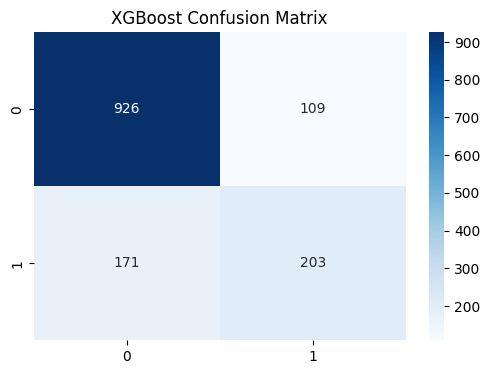

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = xgb_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [15]:
import joblib

joblib.dump(
    xgb_model,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [16]:
import os

os.listdir("../models")

['churn_model.joblib', 'encoders.joblib', 'scaler.joblib']